In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("C:/Users/nchou/Downloads/Global_Superstore2/Global_Superstore2.csv", encoding='latin1')
print(df.shape)
df.head()

(51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [33]:

print(df['Order Date'].dtype)


object


In [34]:
df['Order Date']=pd.to_datetime(
    df['Order Date'],
    dayfirst = True,
    errors = 'coerce'
)
df['Ship Date']=pd.to_datetime(
    df['Ship Date'],
    dayfirst = True,
    errors = 'coerce'
)
print(df[['Order Date','Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


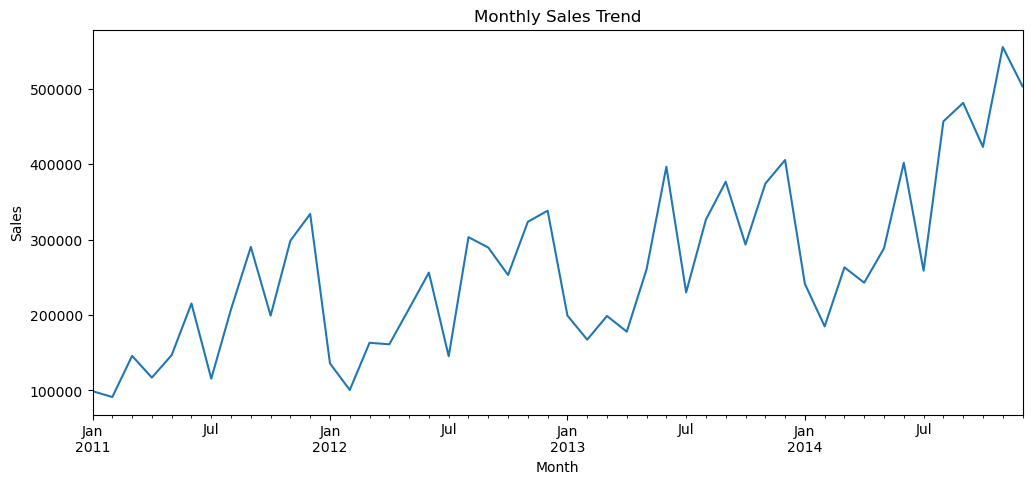

In [35]:
# sales Trend Analysis
monthly_sales = (
    df.groupby(
        df['Order Date'].dt.to_period('M')
    )['Sales']
        .sum()
)

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64


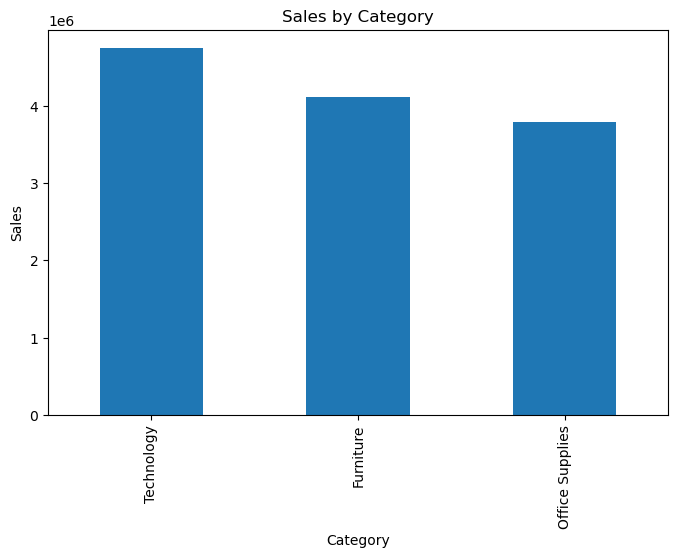

In [36]:
# Category Wise Sales
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

Region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: Sales, dtype: float64


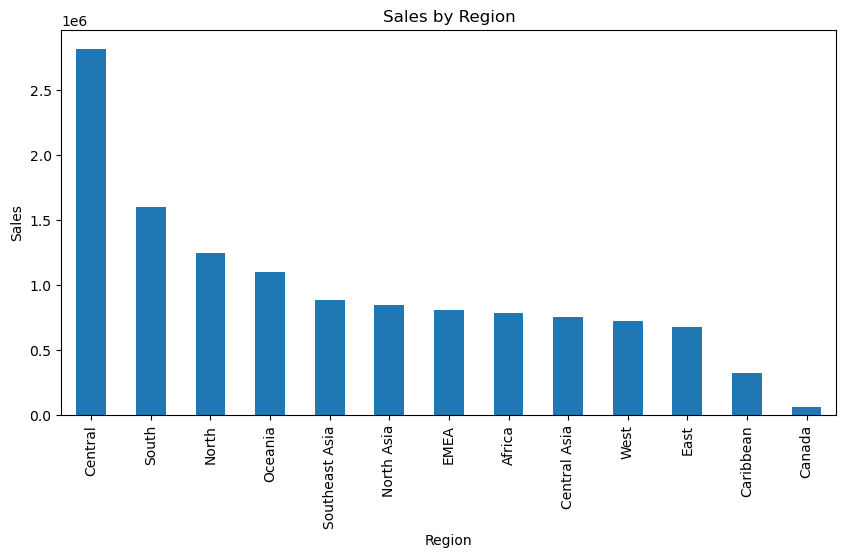

In [37]:
#Region wise sales
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

region_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

Segment
Consumer       6.507949e+06
Corporate      3.824698e+06
Home Office    2.309855e+06
Name: Sales, dtype: float64


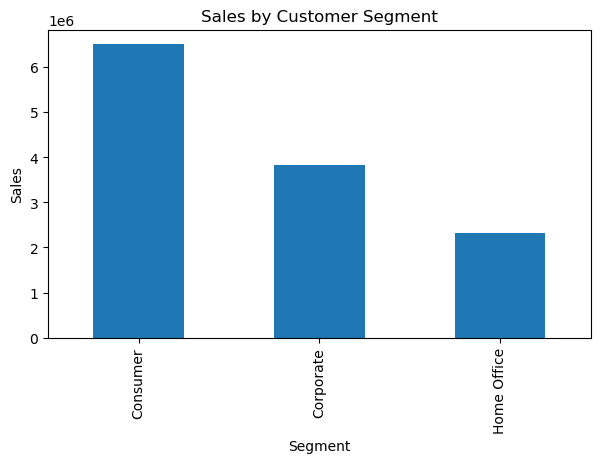

In [38]:
# Segment Analysis
segment_sales=(
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

segment_sales.plot(
    kind='bar',
    figsize = (7,4)
)

plt.title("Sales by Customer Segment")
plt.ylabel("Sales")
plt.show()

In [39]:
# Top 10 products
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: Sales, dtype: float64


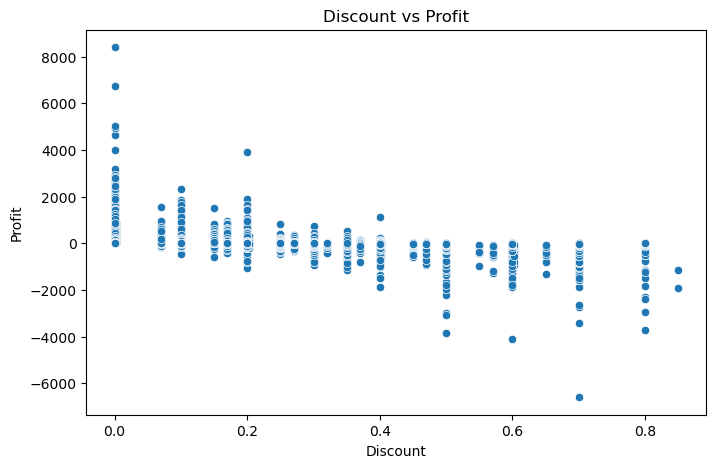

In [42]:
# Discount vs Profit
plt.figure(figsize = (8,5))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title("Discount vs Profit")
plt.show()

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


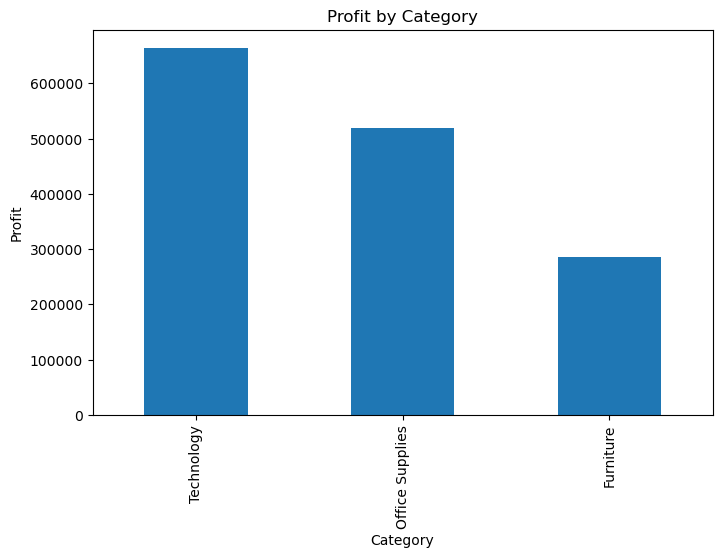

In [43]:
# Category-wise Profit
category_profit = (
    df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

category_profit.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

In [44]:
# Top 10 Product by Sales
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: Sales, dtype: float64


In [46]:
# Top 10 Product by Profit
top_profit_products=(
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64


In [47]:
# Delivery Time Analysis
df['Delivery Days'] = (
    df['Ship Date']-df['Order Date']
).dt.days

print(df['Delivery Days'].describe())

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: Delivery Days, dtype: float64


In [48]:
ship_mode_analysis = (
    df.groupby('Ship Mode')['Delivery Days']
    .mean()
    .sort_values()
)
print(ship_mode_analysis)

Ship Mode
Same Day          0.037394
First Class       2.181746
Second Class      3.230187
Standard Class    4.998018
Name: Delivery Days, dtype: float64
